## Example: 2D simulation of Taylor Green Vortex using Lattice Boltzmann Method


The example solves the Naiver Stokes Equation using Lattice Boltzmann Method. Here we setup the problem using an analytical solution of N-S equation: Taylor Green Vortex. Its velocity field and pressure field can be written as


$$u= -u_{\max} \cos \frac{2\pi x}{L} \sin \frac{2\pi y}{L} e^{-\nu t} $$ 

$$ v=u_{\max}\sin \frac{2\pi x}{L} \cos \frac{2\pi y}{L} e^{-\nu t} $$

$$p= -\frac {1}{4}  \rho_0 u_{\max}^2 ( \cos \frac{2\pi x}{L} + \cos \frac{2\pi y}{L} ) e^{-2\nu t} $$

Here, the Boltzmann equation is written as

$$\frac{\partial f}{\partial t}+ \xi_\alpha \frac{\partial f}{\partial x_\alpha} +\frac{f_\alpha}{\rho}\frac{\partial f}{\partial \xi_\alpha}=\Omega(f),$$

where the probability density function $f(\mathbf{x},\mathbf{\xi}, t)$, which is defined as a function of location $\mathbf{x}$, microscopic particle velocity $\mathbf{\xi}$, and time $t$. $f_\alpha$ is external forcing, and $\Omega(f)$ is the collision term.

The problem is solved in 2D using D2Q9 discretization, and the collision term is solved using BGK operator.


## Running the code

The simulation can be ran as `./mained.gnu.ex inputs`. 

The following inputs parameters could be tweaked:

```
scale = 2              # scale of the problem
max_grid_size = 64                # max grid size used for domain decomposition
Nx = 32    # size of the domain in both directions are Nx*scale
NSTEP=200  # number of time steps is NSTEP*scale*scale
plot_int=50 # interval of saving data, if not save, then set as -1
```


## Visualizating the results

Below we give some python code to visualizate the solution using yt:

In [1]:
import yt
from yt.frontends import boxlib
from yt.frontends.boxlib.data_structures import AMReXDataset

/tmp/ipykernel_61402/3074286631.py:3: DeprecationWarning: The historic 'boxlib' frontend is 
deprecated as it has been renamed 'amrex'. Existing and future work should instead reference the 'amrex' frontend.
Deprecated since yt 4.4.0
  from yt.frontends.boxlib.data_structures import AMReXDataset


yt : [INFO     ] 2025-05-04 16:29:59,353 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-05-04 16:29:59,353 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:29:59,354 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:29:59,355 Parameters: domain_right_edge         = [64. 64.  1.]


Available fields: [('boxlib', 'Pressure'), ('boxlib', 'f_new_0'), ('boxlib', 'f_new_1'), ('boxlib', 'f_new_2'), ('boxlib', 'f_new_3'), ('boxlib', 'f_new_4'), ('boxlib', 'f_new_5'), ('boxlib', 'f_new_6'), ('boxlib', 'f_new_7'), ('boxlib', 'f_new_8'), ('boxlib', 'rho'), ('boxlib', 'ux'), ('boxlib', 'uy'), ('boxlib', 'uz'), ('boxlib', 'vor')]


yt : [INFO     ] 2025-05-04 16:29:59,837 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 16:29:59,838 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 16:29:59,839 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 16:29:59,840 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 16:29:59,842 Making a fixed resolution buffer of (('boxlib', 'ux')) 800 by 800



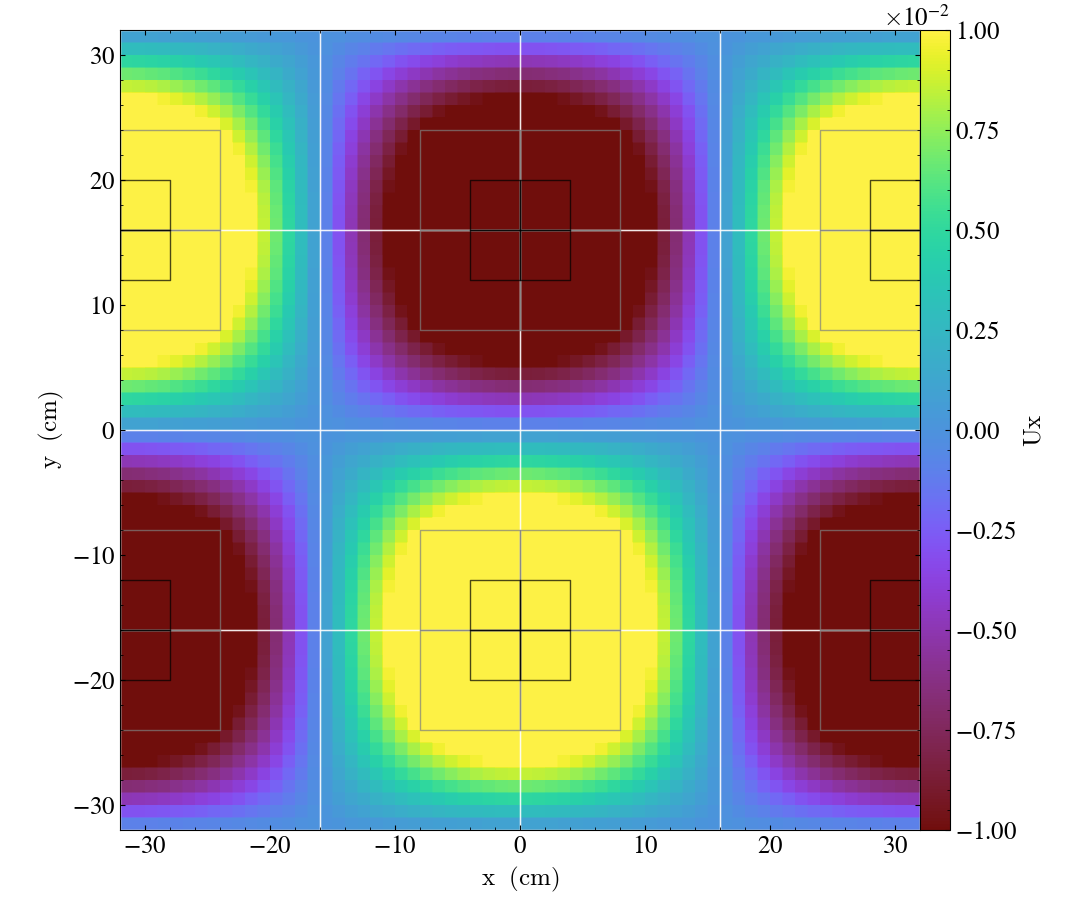

In [2]:
ds = AMReXDataset("./res_multi/plt00000")
print("Available fields:", ds.field_list)
field = ("boxlib", "ux" )

slc = yt.SlicePlot(ds, "z", field)
slc.set_log(field, False)  # Set to True if you want a log scale
slc.annotate_grids()  # Show AMR grid structure
slc.set_zlim(field, -0.01,0.01)

slc.show()
# # Projection plot (integrates field along z-axis)
# proj = yt.ProjectionPlot(ds, "z", field)
# proj.set_log(field, False)
# proj.annotate_grids()
# proj.show()

yt : [INFO     ] 2025-05-04 16:30:00,411 Parameters: current_time              = 300.0
yt : [INFO     ] 2025-05-04 16:30:00,412 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:00,413 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:00,414 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2025-05-04 16:30:00,677 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 16:30:00,678 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 16:30:00,679 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 16:30:00,680 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 16:30:00,681 Making a fixed resolution buffer of (('boxlib', 'ux')) 800 by 800


Available fields: [('boxlib', 'Pressure'), ('boxlib', 'f_new_0'), ('boxlib', 'f_new_1'), ('boxlib', 'f_new_2'), ('boxlib', 'f_new_3'), ('boxlib', 'f_new_4'), ('boxlib', 'f_new_5'), ('boxlib', 'f_new_6'), ('boxlib', 'f_new_7'), ('boxlib', 'f_new_8'), ('boxlib', 'rho'), ('boxlib', 'ux'), ('boxlib', 'uy'), ('boxlib', 'uz'), ('boxlib', 'vor')]



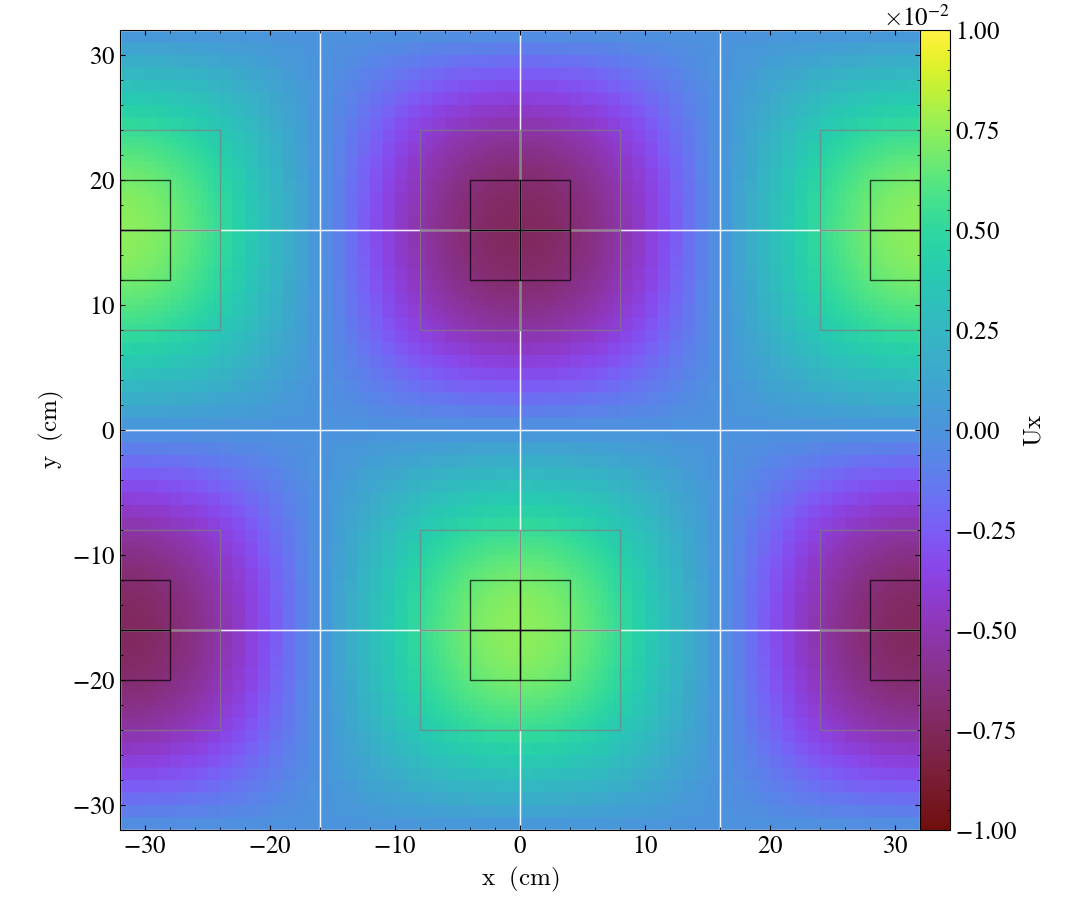

In [3]:
ds = AMReXDataset("./res_multi/plt00300")
print("Available fields:", ds.field_list)
field = ("boxlib", "ux" )

slc = yt.SlicePlot(ds, "z", field)
slc.set_log(field, False)  # Set to True if you want a log scale
slc.annotate_grids()  # Show AMR grid structure
slc.set_zlim(field, -0.01,0.01)

slc.show()
# # Projection plot (integrates field along z-axis)
# proj = yt.ProjectionPlot(ds, "z", field)
# proj.set_log(field, False)
# proj.annotate_grids()
# proj.show()

yt : [INFO     ] 2025-05-04 16:30:01,101 Parameters: current_time              = 900.0
yt : [INFO     ] 2025-05-04 16:30:01,102 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:01,102 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:01,103 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2025-05-04 16:30:01,366 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 16:30:01,367 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 16:30:01,369 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 16:30:01,370 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 16:30:01,371 Making a fixed resolution buffer of (('boxlib', 'ux')) 800 by 800


Available fields: [('boxlib', 'Pressure'), ('boxlib', 'f_new_0'), ('boxlib', 'f_new_1'), ('boxlib', 'f_new_2'), ('boxlib', 'f_new_3'), ('boxlib', 'f_new_4'), ('boxlib', 'f_new_5'), ('boxlib', 'f_new_6'), ('boxlib', 'f_new_7'), ('boxlib', 'f_new_8'), ('boxlib', 'rho'), ('boxlib', 'ux'), ('boxlib', 'uy'), ('boxlib', 'uz'), ('boxlib', 'vor')]



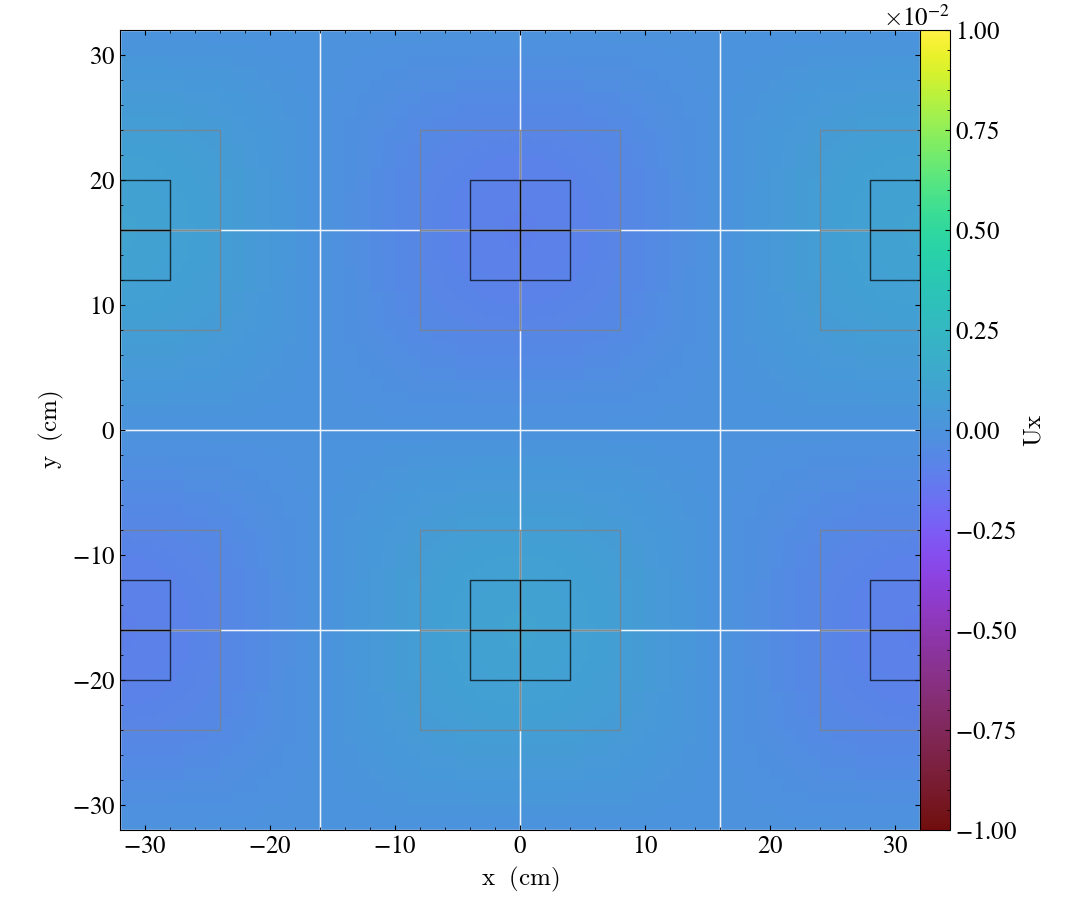

In [4]:
ds = AMReXDataset("./res_multi/plt00900")
print("Available fields:", ds.field_list)
field = ("boxlib", "ux" )

slc = yt.SlicePlot(ds, "z", field)
slc.set_log(field, False)  # Set to True if you want a log scale
slc.annotate_grids()  # Show AMR grid structure
slc.set_zlim(field, -0.01,0.01)

slc.show()
# # Projection plot (integrates field along z-axis)
# proj = yt.ProjectionPlot(ds, "z", field)
# proj.set_log(field, False)
# proj.annotate_grids()
# proj.show()

## Validation of the results using analytical solution

yt : [INFO     ] 2025-05-04 16:30:01,995 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-05-04 16:30:01,996 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:01,996 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:01,997 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2025-05-04 16:30:02,273 Parameters: current_time              = 50.0
yt : [INFO     ] 2025-05-04 16:30:02,273 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:02,274 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:02,274 Parameters: domain_right_edge         = [64. 64.  1.]


t=0.000 code_time: err_ux=0.000e+00, err_uy=0.000e+00, err_rho=0.000e+00


yt : [INFO     ] 2025-05-04 16:30:02,528 Parameters: current_time              = 100.0
yt : [INFO     ] 2025-05-04 16:30:02,529 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:02,530 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:02,530 Parameters: domain_right_edge         = [64. 64.  1.]


t=50.000 code_time: err_ux=2.170e-04, err_uy=2.170e-04, err_rho=3.177e-02


yt : [INFO     ] 2025-05-04 16:30:02,823 Parameters: current_time              = 150.0
yt : [INFO     ] 2025-05-04 16:30:02,823 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:02,824 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:02,824 Parameters: domain_right_edge         = [64. 64.  1.]


...

t=750.000 code_time: err_ux=1.792e-03, err_uy=1.792e-03, err_rho=5.345e-03


yt : [INFO     ] 2025-05-04 16:30:06,686 Parameters: current_time              = 850.0
yt : [INFO     ] 2025-05-04 16:30:06,686 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:06,687 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:06,688 Parameters: domain_right_edge         = [64. 64.  1.]


t=800.000 code_time: err_ux=1.919e-03, err_uy=1.919e-03, err_rho=2.885e-02


yt : [INFO     ] 2025-05-04 16:30:06,954 Parameters: current_time              = 900.0
yt : [INFO     ] 2025-05-04 16:30:06,955 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:06,955 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:06,956 Parameters: domain_right_edge         = [64. 64.  1.]


t=850.000 code_time: err_ux=2.047e-03, err_uy=2.047e-03, err_rho=5.221e-02
t=900.000 code_time: err_ux=2.175e-03, err_uy=2.175e-03, err_rho=5.755e-02


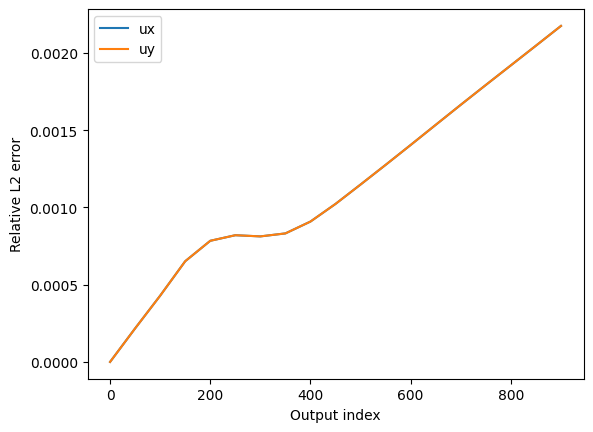

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import yt

L     = 64.0
u_max = 0.02
rho0  = 1.0
kx, ky= 2*np.pi/L, 2*np.pi/L
nu    = 1.0/6.0
td    = 1.0/(nu*(kx*kx+ky*ky))

def u_exact(x,y,z,t):
    decay1 = np.exp(-1.0*t/td)
    decay2 = np.exp(-2.0*t/td)
    ux = -u_max*np.sqrt(ky/kx)*np.cos(kx*x)*np.sin(ky*y)*decay1
    uy =  u_max*np.sqrt(kx/ky)*np.sin(kx*x)*np.cos(ky*y)*decay1
    P  = -0.25*rho0*u_max**2*((ky/kx)*np.cos(2*kx*x)
                             + (kx/ky)*np.cos(2*ky*y))*decay2
    rho= rho0 + 3.0*P
    return ux, uy, rho

times = np.arange(0,950,50)
err_ux, err_uy, err_rho = [], [], []

for idx in times:
    ds = yt.load(f"./res_single/plt{idx:05d}")
    t_phys = ds.current_time

    # —— use all_data() to grab every AMR level at once ——
    ad = ds.all_data()
    x = ad[("index","x")].v
    y = ad[("index","y")].v
    z = ad[("index","z")].v
    vol = ad[("index","cell_volume")].v

    ux_num = ad[("boxlib","ux")].v
    uy_num = ad[("boxlib","uy")].v
    rho_num= ad[("boxlib","rho")].v

    ux_ex, uy_ex, rho_ex = u_exact(x,y,z,t_phys)

    dux = ux_num - ux_ex
    duy = uy_num - uy_ex
    drho= rho_num- rho_ex

    # relative L2 norm, volume-weighted:
    def rel_L2(e, ref):
        return np.sqrt(np.sum(e*e*vol) / np.sum(ref*ref*vol))

    err_ux.append(rel_L2(dux, ux_ex))
    err_uy.append(rel_L2(duy, uy_ex))
    # for density subtract background if desired
    err_rho.append(rel_L2(drho, rho_ex - rho0))

    print(f"t={t_phys:.3f}: err_ux={err_ux[-1]:.3e}, "
          f"err_uy={err_uy[-1]:.3e}, err_rho={err_rho[-1]:.3e}")

# plot the time evolution of the errors
plt.plot(times, err_ux, label='ux')
plt.plot(times, err_uy, label='uy')
# plt.plot(times, err_rho,label='rho')
plt.xlabel('Output index')
plt.ylabel('Relative L2 error')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import yt

L     = 64.0
u_max = 0.02
rho0  = 1.0
kx, ky= 2*np.pi/L, 2*np.pi/L
nu    = 1.0/6.0
td    = 1.0/(nu*(kx*kx+ky*ky))

def u_exact(x,y,z,t):
    decay1 = np.exp(-1.0*t/td)
    decay2 = np.exp(-2.0*t/td)
    ux = -u_max*np.sqrt(ky/kx)*np.cos(kx*x)*np.sin(ky*y)*decay1
    uy =  u_max*np.sqrt(kx/ky)*np.sin(kx*x)*np.cos(ky*y)*decay1
    P  = -0.25*rho0*u_max**2*((ky/kx)*np.cos(2*kx*x)
                             + (kx/ky)*np.cos(2*ky*y))*decay2
    rho= rho0 + 3.0*P
    return ux, uy, rho

times = np.arange(0,950,50)
err_ux, err_uy, err_rho = [], [], []

for idx in times:
    ds = yt.load(f"./res_multi/plt{idx:05d}")
    t_phys = ds.current_time

    # —— use all_data() to grab every AMR level at once ——
    # ad = ds.all_data()
    # x = ad[("index","x")].v
    # y = ad[("index","y")].v
    # z = ad[("index","z")].v
    # vol = ad[("index","cell_volume")].v
    level = ds.max_level
    
    ad = ds.all_data()
    
    cg = ds.covering_grid(level=level,
                      left_edge=ds.domain_left_edge,
                      dims=ds.domain_dimensions * (2**level))
    print(level,ds.domain_dimensions * (2**level))
    ux_num = cg[("boxlib","ux")].v
    uy_num = cg[("boxlib","uy")].v
    rho_num= cg[("boxlib","rho")].v
    print(ux_num.shape)
    dx = ds.domain_width / (ds.domain_dimensions * (2**level))
    
    dims = rho_num.shape

    x = (np.arange(dims[0]) + 0.5) * dx[0] + ds.domain_left_edge[0]
    
    y = (np.arange(dims[1]) + 0.5) * dx[1] + ds.domain_left_edge[1]
    z = (np.arange(dims[2]) + 0.5) * dx[2] + ds.domain_left_edge[2]

    ux_ex, uy_ex, rho_ex = u_exact(x,y,z,t_phys)

    dux = ux_num - ux_ex
    duy = uy_num - uy_ex
    drho= rho_num- rho_ex

    # relative L2 norm, volume-weighted:
    def rel_L2(e, ref):
        return np.sqrt(np.sum(e*e*vol) / np.sum(ref*ref*vol))

    err_ux.append(rel_L2(dux, ux_ex))
    err_uy.append(rel_L2(duy, uy_ex))
    # for density subtract background if desired
    err_rho.append(rel_L2(drho, rho_ex - rho0))

    print(f"t={t_phys:.3f}: err_ux={err_ux[-1]:.3e}, "
          f"err_uy={err_uy[-1]:.3e}, err_rho={err_rho[-1]:.3e}")

# plot the time evolution of the errors
plt.plot(times, err_ux, label='ux')
plt.plot(times, err_uy, label='uy')
# plt.plot(times, err_rho,label='rho')
plt.xlabel('Output index')
plt.ylabel('Relative L2 error')
plt.legend()
plt.show()

yt : [INFO     ] 2025-05-18 10:50:47,908 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-05-18 10:50:47,909 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-18 10:50:47,910 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-18 10:50:47,910 Parameters: domain_right_edge         = [64. 64.  1.]


(256, 256, 4)


ValueError: operands could not be broadcast together with shapes (256,256,4) (256,) 

### first interpolation and then evaluate error

yt : [INFO     ] 2025-05-04 16:30:15,379 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-05-04 16:30:15,380 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:15,380 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:15,381 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2025-05-04 16:30:15,638 Parameters: current_time              = 50.0
yt : [INFO     ] 2025-05-04 16:30:15,639 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:15,640 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:15,640 Parameters: domain_right_edge         = [64. 64.  1.]


t=0.000 code_time: err_ux=3.880e-02, err_uy=3.880e-02, err_rho=5.487e-02


yt : [INFO     ] 2025-05-04 16:30:15,878 Parameters: current_time              = 100.0
yt : [INFO     ] 2025-05-04 16:30:15,878 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:15,879 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:15,879 Parameters: domain_right_edge         = [64. 64.  1.]


t=50.000 code_time: err_ux=3.880e-02, err_uy=3.880e-02, err_rho=6.265e-02


yt : [INFO     ] 2025-05-04 16:30:16,178 Parameters: current_time              = 150.0
yt : [INFO     ] 2025-05-04 16:30:16,179 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:16,179 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:16,180 Parameters: domain_right_edge         = [64. 64.  1.]


...

t=750.000 code_time: err_ux=3.881e-02, err_uy=3.881e-02, err_rho=5.501e-02


yt : [INFO     ] 2025-05-04 16:30:19,699 Parameters: current_time              = 850.0
yt : [INFO     ] 2025-05-04 16:30:19,699 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:19,700 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:19,700 Parameters: domain_right_edge         = [64. 64.  1.]


t=800.000 code_time: err_ux=3.881e-02, err_uy=3.881e-02, err_rho=6.269e-02


yt : [INFO     ] 2025-05-04 16:30:19,963 Parameters: current_time              = 900.0
yt : [INFO     ] 2025-05-04 16:30:19,964 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:19,964 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:19,965 Parameters: domain_right_edge         = [64. 64.  1.]


t=850.000 code_time: err_ux=3.882e-02, err_uy=3.882e-02, err_rho=7.677e-02
t=900.000 code_time: err_ux=3.882e-02, err_uy=3.882e-02, err_rho=8.060e-02


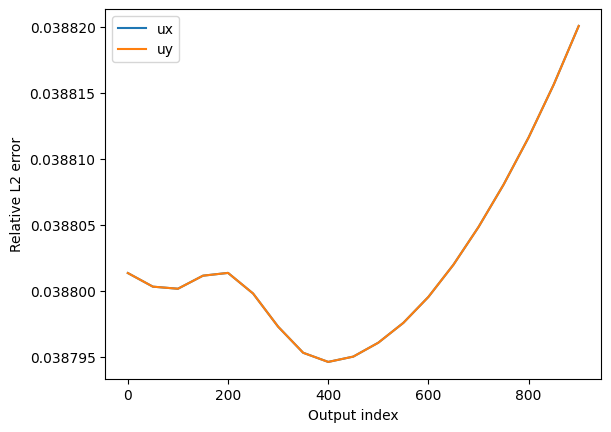

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import yt

# physical & sim parameters
L     = 64.0
u_max = 0.02
rho0  = 1.0
kx, ky= 2*np.pi/L, 2*np.pi/L
nu    = 1.0/6.0
td    = 1.0/(nu*(kx*kx + ky*ky))

def u_exact(x, y, z, t):
    decay1 = np.exp(-1.0*t/td)
    decay2 = np.exp(-2.0*t/td)
    ux = -u_max*np.sqrt(ky/kx)*np.cos(kx*x)*np.sin(ky*y)*decay1
    uy =  u_max*np.sqrt(kx/ky)*np.sin(kx*x)*np.cos(ky*y)*decay1
    P  = -0.25*rho0*u_max**2*((ky/kx)*np.cos(2*kx*x)
                             + (kx/ky)*np.cos(2*ky*y))*decay2
    rho= rho0 + 3.0*P
    return ux, uy, rho

# choose uniform‐mesh resolution for error evaluation
nx = ny = 256
nz = 1      # for a 2D slice

# construct the cell‐center coordinates once
x_lin = np.linspace(0 + L/nx/2, L - L/nx/2, nx)
y_lin = np.linspace(0 + L/ny/2, L - L/ny/2, ny)
z_lin = np.array([0.5]) if nz==1 else np.linspace(0 + L/nz/2, L - L/nz/2, nz)

# meshgrid & flatten
Xg, Yg, Zg = np.meshgrid(x_lin, y_lin, z_lin, indexing='ij')
pts         = np.vstack([Xg.ravel(), Yg.ravel(), Zg.ravel()]).T
Npts        = pts.shape[0]
domain_vol  = L*L * (L if nz>1 else 1.0)
vol_cell    = domain_vol / Npts

times   = np.arange(0, 950, 50)
err_ux  = []
err_uy  = []
err_rho = []

for idx in times:
    ds = yt.load(f"./res_single/plt{idx:05d}")
    ds.force_periodicity()
    t_phys = ds.current_time

    # ── create a uniform box [0,64]^2×[0,1] with dims=(nx,ny,nz)
    ug = ds.arbitrary_grid(
        left_edge  = ds.domain_left_edge,
        right_edge = ds.domain_right_edge,
        dims       = (nx, ny, nz)
    )

    # pull interpolated arrays (each of shape (nx,ny,nz))
    ux_arr = ug[("boxlib","ux")].v.ravel()
    uy_arr = ug[("boxlib","uy")].v.ravel()
    ro_arr = ug[("boxlib","rho")].v.ravel()

    # exact solution on same points
    ux_e, uy_e, ro_e = u_exact(pts[:,0], pts[:,1], pts[:,2], t_phys)

    # L2‐error integrals
    err2_ux  = np.sum((ux_arr - ux_e)**2) * vol_cell
    ref2_ux  = np.sum( ux_e**2      ) * vol_cell

    err2_uy  = np.sum((uy_arr - uy_e)**2) * vol_cell
    ref2_uy  = np.sum( uy_e**2      ) * vol_cell

    err2_rho = np.sum((ro_arr - ro_e)**2) * vol_cell
    ref2_rho = np.sum((ro_e - rho0)**2) * vol_cell

    err_ux.append(  np.sqrt(err2_ux  / ref2_ux)  )
    err_uy.append(  np.sqrt(err2_uy  / ref2_uy)  )
    err_rho.append( np.sqrt(err2_rho / ref2_rho) )

    print(f"t={t_phys:.3f}: err_ux={err_ux[-1]:.3e}, "
          f"err_uy={err_uy[-1]:.3e}, err_rho={err_rho[-1]:.3e}")

# plot
plt.plot(times, err_ux,  label='ux')
plt.plot(times, err_uy,  label='uy')
# plt.plot(times, err_rho, label='rho')
plt.xlabel('Output index')
plt.ylabel('Relative L2 error')
plt.legend()
plt.show()


yt : [INFO     ] 2025-05-04 16:30:20,300 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-05-04 16:30:20,301 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:20,302 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:20,303 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2025-05-04 16:30:20,716 Parameters: current_time              = 50.0
yt : [INFO     ] 2025-05-04 16:30:20,717 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:20,718 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:20,719 Parameters: domain_right_edge         = [64. 64.  1.]


t=0.000 code_time: err_ux=3.637e-02, err_uy=3.638e-02, err_rho=4.894e-02


yt : [INFO     ] 2025-05-04 16:30:21,274 Parameters: current_time              = 100.0
yt : [INFO     ] 2025-05-04 16:30:21,275 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:21,275 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:21,276 Parameters: domain_right_edge         = [64. 64.  1.]


t=50.000 code_time: err_ux=3.676e-02, err_uy=3.679e-02, err_rho=3.087e-01


yt : [INFO     ] 2025-05-04 16:30:21,706 Parameters: current_time              = 150.0
yt : [INFO     ] 2025-05-04 16:30:21,706 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:21,707 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:21,708 Parameters: domain_right_edge         = [64. 64.  1.]


...

t=750.000 code_time: err_ux=7.107e-02, err_uy=6.982e-02, err_rho=2.768e+00


yt : [INFO     ] 2025-05-04 16:30:28,824 Parameters: current_time              = 850.0
yt : [INFO     ] 2025-05-04 16:30:28,824 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:28,825 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:28,825 Parameters: domain_right_edge         = [64. 64.  1.]


t=800.000 code_time: err_ux=7.501e-02, err_uy=7.256e-02, err_rho=1.161e+00


yt : [INFO     ] 2025-05-04 16:30:29,622 Parameters: current_time              = 900.0
yt : [INFO     ] 2025-05-04 16:30:29,623 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 16:30:29,623 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 16:30:29,624 Parameters: domain_right_edge         = [64. 64.  1.]


t=850.000 code_time: err_ux=7.618e-02, err_uy=7.815e-02, err_rho=2.357e+00
t=900.000 code_time: err_ux=8.190e-02, err_uy=7.925e-02, err_rho=4.099e+00


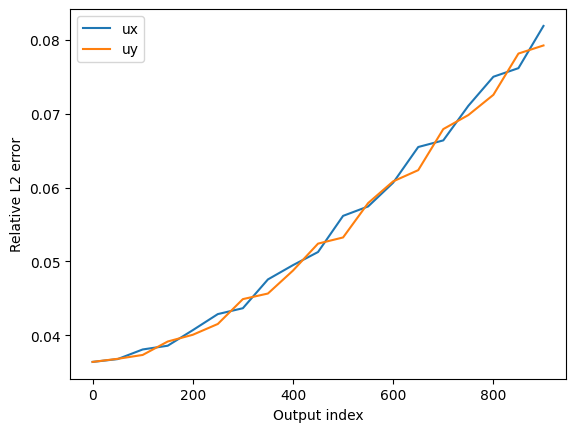

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import yt

# physical & sim parameters
L     = 64.0
u_max = 0.02
rho0  = 1.0
kx, ky= 2*np.pi/L, 2*np.pi/L
nu    = 1.0/6.0
td    = 1.0/(nu*(kx*kx + ky*ky))

def u_exact(x, y, z, t):
    decay1 = np.exp(-1.0*t/td)
    decay2 = np.exp(-2.0*t/td)
    ux = -u_max*np.sqrt(ky/kx)*np.cos(kx*x)*np.sin(ky*y)*decay1
    uy =  u_max*np.sqrt(kx/ky)*np.sin(kx*x)*np.cos(ky*y)*decay1
    P  = -0.25*rho0*u_max**2*((ky/kx)*np.cos(2*kx*x)
                             + (kx/ky)*np.cos(2*ky*y))*decay2
    rho= rho0 + 3.0*P
    return ux, uy, rho

# choose uniform‐mesh resolution for error evaluation
nx = ny = 256
nz = 1      # for a 2D slice

# construct the cell‐center coordinates once
x_lin = np.linspace(0 + L/nx/2, L - L/nx/2, nx)
y_lin = np.linspace(0 + L/ny/2, L - L/ny/2, ny)
z_lin = np.array([0.5]) if nz==1 else np.linspace(0 + L/nz/2, L - L/nz/2, nz)

# meshgrid & flatten
Xg, Yg, Zg = np.meshgrid(x_lin, y_lin, z_lin, indexing='ij')
pts         = np.vstack([Xg.ravel(), Yg.ravel(), Zg.ravel()]).T
Npts        = pts.shape[0]
domain_vol  = L*L * (L if nz>1 else 1.0)
vol_cell    = domain_vol / Npts

times   = np.arange(0, 950, 50)
err_ux  = []
err_uy  = []
err_rho = []

for idx in times:
    ds = yt.load(f"./res_multi/plt{idx:05d}")
    ds.force_periodicity()
    t_phys = ds.current_time

    # ── create a uniform box [0,64]^2×[0,1] with dims=(nx,ny,nz)
    ug = ds.arbitrary_grid(
        left_edge  = ds.domain_left_edge,
        right_edge = ds.domain_right_edge,
        dims       = (nx, ny, nz)
    )

    # pull interpolated arrays (each of shape (nx,ny,nz))
    ux_arr = ug[("boxlib","ux")].v.ravel()
    uy_arr = ug[("boxlib","uy")].v.ravel()
    ro_arr = ug[("boxlib","rho")].v.ravel()

    # exact solution on same points
    ux_e, uy_e, ro_e = u_exact(pts[:,0], pts[:,1], pts[:,2], t_phys)

    # L2‐error integrals
    err2_ux  = np.sum((ux_arr - ux_e)**2) * vol_cell
    ref2_ux  = np.sum( ux_e**2      ) * vol_cell

    err2_uy  = np.sum((uy_arr - uy_e)**2) * vol_cell
    ref2_uy  = np.sum( uy_e**2      ) * vol_cell

    err2_rho = np.sum((ro_arr - ro_e)**2) * vol_cell
    ref2_rho = np.sum((ro_e - rho0)**2) * vol_cell

    err_ux.append(  np.sqrt(err2_ux  / ref2_ux)  )
    err_uy.append(  np.sqrt(err2_uy  / ref2_uy)  )
    err_rho.append( np.sqrt(err2_rho / ref2_rho) )

    print(f"t={t_phys:.3f}: err_ux={err_ux[-1]:.3e}, "
          f"err_uy={err_uy[-1]:.3e}, err_rho={err_rho[-1]:.3e}")

# plot
plt.plot(times, err_ux,  label='ux')
plt.plot(times, err_uy,  label='uy')
# plt.plot(times, err_rho, label='rho')
plt.xlabel('Output index')
plt.ylabel('Relative L2 error')
plt.legend()
plt.show()
